In [216]:
import pandas as pd
from openai import OpenAI
from pprint import pprint
import numpy as np
from dotenv import load_dotenv

load_dotenv()

client = OpenAI()

In [217]:
answers = pd.read_csv("answers.csv")

In [218]:
answers

,Product No.,Question No.,GPT-4.5,Gemini Pro 2.0 Exp,Claude 3.7 Sonnet,Participant-a,Participant-b,Participant-c,Participant-d,Participant-e
0,1,1,My initial impression of this jacket is quite ...,"Okay, at first glance, this looks like a prett...","This pink raincoat has a fresh, feminine look ...",It's a nice muted kind of light pinky tone. An...,So just my initial thoughts when I opened the ...,"Okay. Yeah. First, like the first thing that g...","It's very bright. I think the material, it loo...",I kinda like it. It's a cute jacket. That was ...
1,1,2,This jacket could be easily styled with casual...,This raincoat looks like it would be great for...,This light pink raincoat would pair beautifull...,Yeah. I think you could do a lot with this. Bu...,I guess like for me as to wear this jacket I'd...,"Yeah, I think because it's like very bright, t...","Probably, this looks really great with legging...",So this jacket would go well with pants to me ...
2,1,3,This jacket has some practical features design...,"Based on the images, this jacket has a few key...","Looking at these images, this peach/pink rainc...",I like that question 'cause that's what I look...,Yes. I guess like the first thing I noticed in...,"I think honestly, looking at it in detail, I t...","I guess the, as I mentioned before, the materi...","Okay, so there's definitely zippers. There's a..."
3,1,4,"This jacket seems versatile and casual, ideal ...","Based on the images, this jacket seems perfect...","From the images, this pink raincoat would be p...",The pink like rain cap coat rainy weather. An...,"It's pretty suitable. Like you have the hood, ...","I could see like someone wearing it, like I sa...",I think it depends on the weather. So if it's ...,I would see this more as like a commuting or ...
4,2,1,My initial thoughts about this product are pos...,"Okay, at first glance, this dress looks really...","Looking at these images, this appears to be a ...",I'm not sure if there's a specific cultural ti...,I guess like my initial reaction when I opened...,"Yeah, so the first thing I saw was like, it's ...","Overall, I think it's the style is nice, the c...","My first impression is very patterned, very co..."
5,2,2,"This colorful, bohemian-style dress could be s...",This dress looks like it would be super versat...,This sundress would be perfect for warm weathe...,"Mix and match, maybe maybe a jean jacket. I wo...",I'd say either some nice or I think the clothi...,"I think like I said, based off of the model, s...",Inside the little pictures I can see like some...,To me it's like a dress. I wouldn't wear pants...
6,2,3,"The dress has two side pockets, which can be u...","Based on the images, the dress has a couple of...","Looking at these images of the summer dress, I...",She's got two pockets and that's great. 'cause...,Like for material I noticed that there's like ...,"Yeah, I would say based off the pictures, it l...","It's not tight at all. It's nice and loose, so...",The pockets. I think that's what they're tryi...
7,2,4,This dress is suitable for casual or semi-casu...,"Based on the images, this dress looks like it ...","Based on the images, this dress would be perfe...",Like a outdoor barbecue or even a nice little ...,"Yeah, for sure. I'd say like festivals and pic...","Yeah like I said before, I really, it, I think...","Think this would be more casual, so going to t...","That would be something to where, vacation, su..."
8,3,1,My initial impression of this product is quite...,"Okay, at first glance, this bag seems pretty s...",This crossbody bag has a sophisticated color-b...,"It's cool, it's practical. I love these photos...",I guess the thing that stands out to me becaus...,"Okay. Yeah. First thing I noticed, it's pretty...",So my first impression of a product it looks l...,My first impression is that this is an all ro...
9,3,2,"This crossbody bag has a stylish, casual feel ...","Given its casual, color-blocked design and pat...","Based on the images, t

In [219]:
answers_list = answers.iloc[:, 2:].values.flatten().tolist()

In [220]:
response = client.embeddings.create(
    input=answers_list,
    model="text-embedding-3-large"
)
answers_embeddings = [d.embedding for d in response.data]

In [221]:
answers_embeddings_array = np.array(answers_embeddings)

In [222]:
answers_embeddings_array.shape

(96, 3072)

In [223]:
# Apply t-SNE to reduce dimensionality to 2D for visualization
from sklearn.manifold import TSNE

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)


# Apply t-SNE transformation
embeddings_2d = tsne.fit_transform(answers_embeddings_array)

# Display the shape of the reduced embeddings
print(embeddings_2d.shape)


(96, 2)


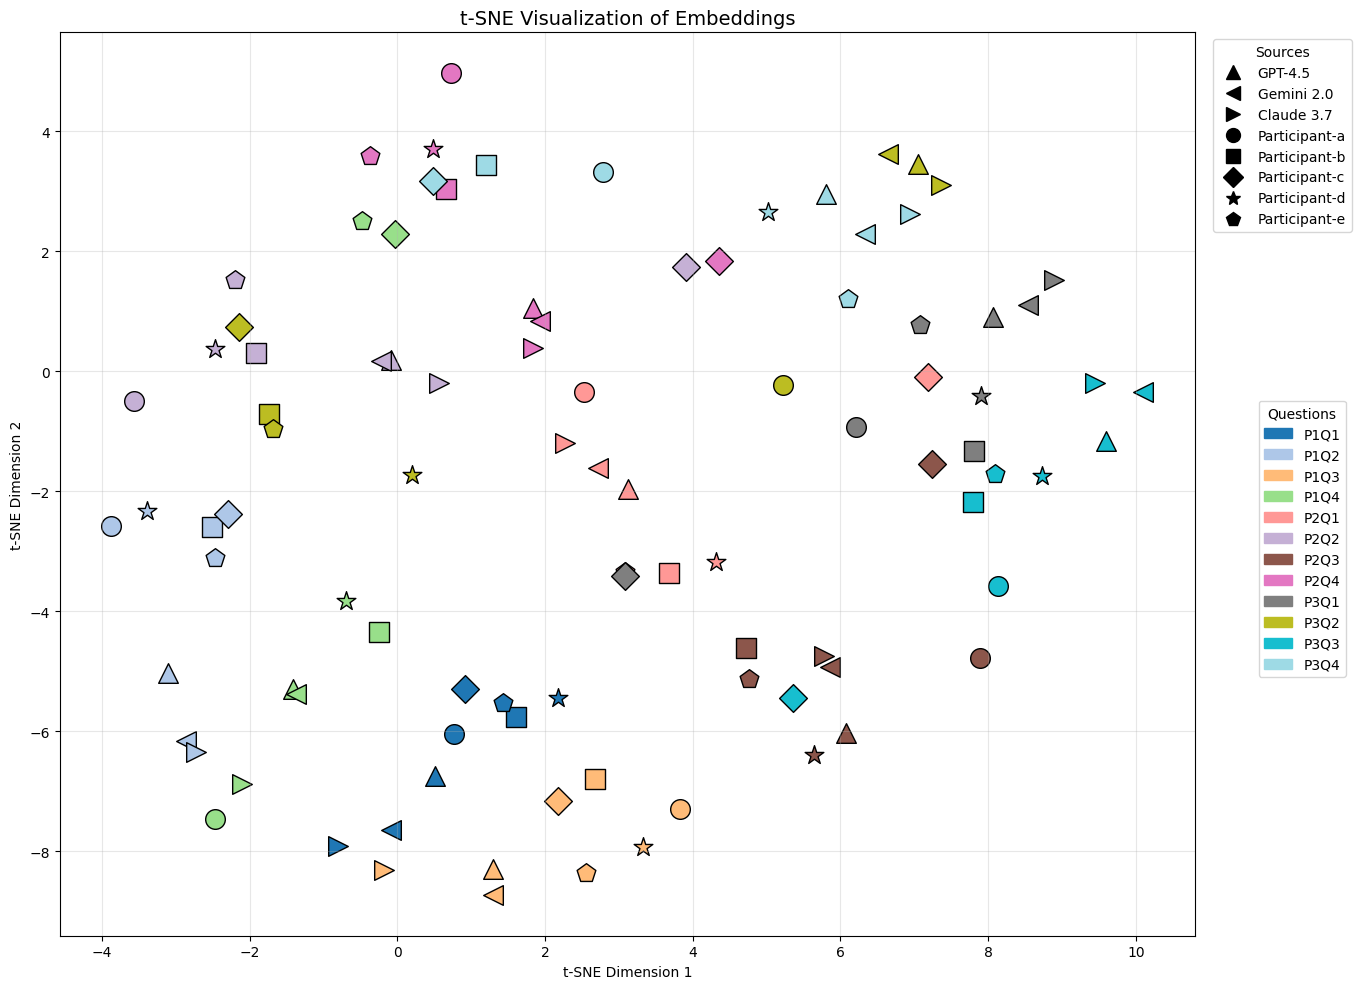

In [224]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


sources = ['GPT-4.5', 'Gemini 2.0', 'Claude 3.7', 'Participant-a', 'Participant-b', 'Participant-c', 'Participant-d', 'Participant-e']
source_markers = {'GPT-4.5': '^', 'Gemini 2.0': '<', 'Claude 3.7': '>', 
                 'Participant-a': 'o', 'Participant-b': 's', 'Participant-c': 'D', 'Participant-d': '*', 'Participant-e': 'p'}

# Define the 12 property groups
property_groups = ['P1Q1', 'P1Q2', 'P1Q3', 'P1Q4', 
                  'P2Q1', 'P2Q2', 'P2Q3', 'P2Q4', 
                  'P3Q1', 'P3Q2', 'P3Q3', 'P3Q4']
                  
# Create color map for property groups
colors = plt.cm.tab20(np.linspace(0, 1, 12))

# Create figure with extra space for the legend
fig, ax = plt.subplots(figsize=(16, 10))

# Assign source and property group to each data point
n_points = len(embeddings_2d)
point_sources = [sources[i % 8] for i in range(n_points)]
point_groups = [property_groups[(i // 8) % 12] for i in range(n_points)]

# Create a scatter plot
for i, (x, y) in enumerate(embeddings_2d):
    source = point_sources[i]
    group = point_groups[i]
    group_idx = property_groups.index(group)
    
    plt.scatter(
        x, y,
        marker=source_markers[source],
        color=colors[group_idx],
        s=200,  # Size of marker
        alpha=1,  # Slight transparency
        edgecolors='black'  # Outline for better visibility
    )

# Create legend elements for sources (different shapes)
source_legend_elements = [
    Line2D([0], [0], marker=marker, color='black', linestyle='None',
           markersize=10, label=source) 
    for source, marker in source_markers.items()
]

# Create legend elements for property groups (different colors)
property_legend_elements = [
    mpatches.Patch(color=colors[i], label=group)
    for i, group in enumerate(property_groups)
]

# Add source legend on the right
first_legend = ax.legend(handles=source_legend_elements, 
                        title="Sources", 
                        loc='upper left', 
                        bbox_to_anchor=(1.01, 1))
ax.add_artist(first_legend)  # Add the legend as an artist to preserve it

# Add property group legend below the first one
ax.legend(handles=property_legend_elements, 
         title="Questions", 
         loc='upper left', 
         bbox_to_anchor=(1.05, 0.6))

# Title and labels
plt.title('t-SNE Visualization of Embeddings', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Add grid for better readability
plt.grid(alpha=0.3)

# Adjust layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # Make room for legend on the right

plt.show()

In [215]:
point_groups

['P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q1',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q2',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q3',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P1Q4',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q1',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q2',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q3',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P2Q4',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q1',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q2',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q3',
 'P3Q4',
 'P3Q4',
 'P3Q4',
 'P3Q4',
 'P3Q4',
 'P3Q4',
 'P3Q4',
 'P3Q4']